In [1]:
#!/usr/bin/env python
# -*- encoding: utf-8
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import itertools as itools
from dask.distributed import Client, LocalCluster
import core_scripts
from core_scripts import *

SyntaxError: f-string: unmatched '(' (precursor_projection.py, line 81)

In [2]:
models = ["IPSL-CM6A-LR"]#["BCC-ESM1"]#["NorESM2-MM"]#["NorESM2-MM"]#
no_members = 1

members = [f"r{r}i1p1f1" for r in range(1, no_members+1)]
# members = ["r1i1p1f1", "r2i1p1f1", "r3i1p1f1"]
experiments = ["ssp370"]	
# combinations = [
#     f"--{model} --{member} --{experiment}"
#     for model, member, experiment
#         in itools.product(models, members, experiments)]
combinations = [
    dict(zip(["model", "experiment", "member"],[model, experiment, member]))
    for model, experiment, member
        in itools.product(models, experiments, members)]
combinations

[{'model': 'IPSL-CM6A-LR', 'experiment': 'ssp370', 'member': 'r1i1p1f1'}]

In [3]:
for combination in combinations:
    model, experiment, member = combination.values()
    z500_detrend.run_z500_detrend(model, experiment, member)

In [2]:
original_path = "/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/raw/NorESM2-LM/z500/historical/z500_day_NorESM2-LM_historical_r2i1p1f1_gn_19500101-20141231.nc"
detrend_path = "/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/raw/NorESM2-LM/z500_detrend/historical/z500_detrend_day_NorESM2-LM_historical_r1i1p1f1_gn_19500101-20141231.nc"
era5_path = "/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/aux/cycles/ERA5.nc"
ds_original = xr.open_dataset(original_path)
ds_detrend = xr.open_dataset(detrend_path)
ds_era5 = xr.open_dataset(era5_path)

In [3]:
ds_original

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 23725, bnds: 2, lat: 96, lon: 144)
Coordinates:
  * time       (time) object 190kB 1950-01-01 12:00:00 ... 2014-12-31 12:00:00
    plev       float64 8B ...
  * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon        (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 380kB ...
    lat_bnds   (time, lat, bnds) float64 36MB ...
    lon_bnds   (time, lon, bnds) float64 55MB ...
    zg         (time, lat, lon) float32 1GB ...
Attributes: (12/50)
    Conventions:                     CF-1.7 CMIP-6.2
    activity_id:                     CMIP
    branch_method:                   Hybrid-restart from year 1631-01-01 of p...
    branch_time:                     0.0
    branch_time_in_child:            0.0
    branch_time_in_parent:           441650.0
    ...                              ...
    variable_id:                     zg
    variant_label:                   r2i1p1f1
    license:                         CMIP6 model data produced by NCC is lice...
    cmor_version:                    3.5.0
    tracking_id:                     hdl:21.14100/7acc7092-2469-4c16-a2bb-3cc...
    DODS_EXTRA.Unlimited_Dimension:  time

In [4]:
ds_detrend

<xarray.Dataset> Size: 793MB
Dimensions:     (lat: 29, lon: 144, time: 23725)
Coordinates:
    plev        float64 8B ...
  * lat         (lat) float64 232B 31.26 33.16 35.05 36.95 ... 80.53 82.42 84.32
  * lon         (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    year        (time) int64 190kB ...
    month       (time) int64 190kB ...
  * time        (time) object 190kB 1950-01-01 12:00:00 ... 2014-12-31 12:00:00
Data variables:
    zg_detrend  (time, lat, lon) float64 793MB ...

In [5]:
ds_era5

<xarray.Dataset> Size: 134MB
Dimensions:       (time: 366, lat: 71, lon: 161)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2000-01-01 2000-01-02 ... 2000-12-31
  * lon           (lon) float32 644B -100.0 -99.0 -98.0 -97.0 ... 58.0 59.0 60.0
  * lat           (lat) float32 284B 15.0 16.0 17.0 18.0 ... 82.0 83.0 84.0 85.0
Data variables:
    z500          (time, lat, lon) float64 33MB ...
    u850          (time, lat, lon) float64 33MB ...
    v850          (time, lat, lon) float64 33MB ...
    z500_detrend  (time, lat, lon) float64 33MB ...
Attributes:
    standard_name:  geopotential
    long_name:      Geopotential
    units:          m**2 s**-2

In [6]:
ds_original.lat.values, ds_original.lon.values

(array([-90.        , -88.10526316, -86.21052632, -84.31578947,
        -82.42105263, -80.52631579, -78.63157895, -76.73684211,
        -74.84210526, -72.94736842, -71.05263158, -69.15789474,
        -67.26315789, -65.36842105, -63.47368421, -61.57894737,
        -59.68421053, -57.78947368, -55.89473684, -54.        ,
        -52.10526316, -50.21052632, -48.31578947, -46.42105263,
        -44.52631579, -42.63157895, -40.73684211, -38.84210526,
        -36.94736842, -35.05263158, -33.15789474, -31.26315789,
        -29.36842105, -27.47368421, -25.57894737, -23.68421053,
        -21.78947368, -19.89473684, -18.        , -16.10526316,
        -14.21052632, -12.31578947, -10.42105263,  -8.52631579,
         -6.63157895,  -4.73684211,  -2.84210526,  -0.94736842,
          0.94736842,   2.84210526,   4.73684211,   6.63157895,
          8.52631579,  10.42105263,  12.31578947,  14.21052632,
         16.10526316,  18.        ,  19.89473684,  21.78947368,
         23.68421053,  25.57894737,  27.

In [7]:
ds_detrend.lat.values, ds_detrend.lon.values

(array([31.26315789, 33.15789474, 35.05263158, 36.94736842, 38.84210526,
        40.73684211, 42.63157895, 44.52631579, 46.42105263, 48.31578947,
        50.21052632, 52.10526316, 54.        , 55.89473684, 57.78947368,
        59.68421053, 61.57894737, 63.47368421, 65.36842105, 67.26315789,
        69.15789474, 71.05263158, 72.94736842, 74.84210526, 76.73684211,
        78.63157895, 80.52631579, 82.42105263, 84.31578947]),
 array([  0. ,   2.5,   5. ,   7.5,  10. ,  12.5,  15. ,  17.5,  20. ,
         22.5,  25. ,  27.5,  30. ,  32.5,  35. ,  37.5,  40. ,  42.5,
         45. ,  47.5,  50. ,  52.5,  55. ,  57.5,  60. ,  62.5,  65. ,
         67.5,  70. ,  72.5,  75. ,  77.5,  80. ,  82.5,  85. ,  87.5,
         90. ,  92.5,  95. ,  97.5, 100. , 102.5, 105. , 107.5, 110. ,
        112.5, 115. , 117.5, 120. , 122.5, 125. , 127.5, 130. , 132.5,
        135. , 137.5, 140. , 142.5, 145. , 147.5, 150. , 152.5, 155. ,
        157.5, 160. , 162.5, 165. , 167.5, 170. , 172.5, 175. , 177.5,
     

In [8]:
lat_test = ds_detrend.lat.isel(lat=16).values
lon_test = ds_detrend.lon.isel(lon=2).values
lat_test, lon_test

(array(61.57894737), array(5.))

In [9]:
zg_detrend_test = ds_detrend.zg_detrend
zg_detrend_test

<xarray.DataArray 'zg_detrend' (time: 23725, lat: 29, lon: 144)> Size: 793MB
[99075600 values with dtype=float64]
Coordinates:
    plev     float64 8B ...
  * lat      (lat) float64 232B 31.26 33.16 35.05 36.95 ... 80.53 82.42 84.32
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    year     (time) int64 190kB ...
    month    (time) int64 190kB ...
  * time     (time) object 190kB 1950-01-01 12:00:00 ... 2014-12-31 12:00:00
Attributes:
    standard_name:  geopotential_height
    long_name:      Geopotential Height
    comment:        Geopotential is the sum of the specific gravitational pot...
    units:          m
    original_name:  Z3
    cell_methods:   time: mean
    cell_measures:  area: areacella
    history:        2019-08-15T18:43:52Z altered by CMOR: Converted type from...
    _ChunkSizes:    [  1   8  96 144]

In [10]:
zg_original_test = ds_original.zg.sel(lat=ds_detrend.lat, lon=ds_detrend.lon)
zg_original_test

<xarray.DataArray 'zg' (time: 23725, lat: 29, lon: 144)> Size: 396MB
[99075600 values with dtype=float32]
Coordinates:
  * time     (time) object 190kB 1950-01-01 12:00:00 ... 2014-12-31 12:00:00
    plev     float64 8B ...
  * lat      (lat) float64 232B 31.26 33.16 35.05 36.95 ... 80.53 82.42 84.32
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    standard_name:  geopotential_height
    long_name:      Geopotential Height
    comment:        Geopotential is the sum of the specific gravitational pot...
    units:          m
    original_name:  Z3
    cell_methods:   time: mean
    cell_measures:  area: areacella
    history:        2019-10-16T00:53:47Z altered by CMOR: Converted type from...
    _ChunkSizes:    [  1   8  96 144]

In [11]:
# Weighted mean lat/lon
weights = np.cos(np.deg2rad(ds_original.lat))
zg_original_test = zg_original_test.weighted(weights).mean(('lat', 'lon'))
zg_detrend_test = zg_detrend_test.weighted(weights).mean(('lat', 'lon'))

In [14]:
zg_original_test.time

<xarray.DataArray 'time' (time: 23725)> Size: 190kB
array([cftime.DatetimeNoLeap(1950, 1, 1, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1950, 1, 2, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1950, 1, 3, 12, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2014, 12, 29, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2014, 12, 30, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2014, 12, 31, 12, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 190kB 1950-01-01 12:00:00 ... 2014-12-31 12:00:00
    plev     float64 8B 5e+04

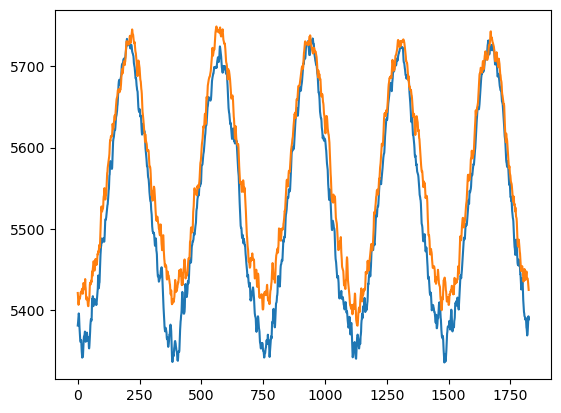

In [24]:
no_years = 5
offset_years = 30
plt.plot(zg_original_test.isel(time=slice(365*offset_years ,365*(no_years+offset_years))))
plt.plot(zg_detrend_test.isel(time=slice(365*offset_years ,365*(no_years+offset_years))))

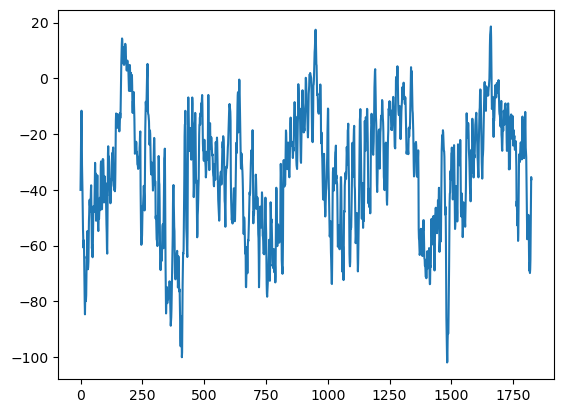

In [25]:
plt.plot((zg_original_test-zg_detrend_test).isel(time=slice(365*offset_years ,365*(no_years+offset_years))))